<h2>Objectifs</h2>

Dans ce fichier, nous cherchons à mettre en forme les bases de données relatives aux trois axes dont nous cherchons à estimer le débit de voitures et le taux d'occupation (les champs Élysées, rue de la Convention, et la rue des Saints-Pères). Pour ce faire, nous allons utiliser les données brutes extraites, puis les retraiter afin de faire face aux données manquantes, ajouter des features (comme la météo, des données sur les vacances, des éventuels évènements dans Paris, des perturbations telles que des chantiers sur les axes d'intérêt directement ou sur les axes voisins...). 

Imports :

In [1]:
import pandas as pd
from pandas.api.types import is_datetime64_any_dtype as is_dt
from pandas.api.types import is_datetime64tz_dtype as is_dt_tz

Tout d'abord, nous allons déterminer comment se présente les données, c'est à dire le type de chaque colonne, le nombre de données non-nulles pour les variables numériques et les valeurs possibles prises pour les variables catégorielles. 

In [2]:
df = pd.read_csv('./dataset/champs_elysees.csv', sep=";")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9266 entries, 0 to 9265
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Identifiant arc            9266 non-null   int64  
 1   Libelle                    9266 non-null   object 
 2   Date et heure de comptage  9266 non-null   object 
 3   Débit horaire              8703 non-null   float64
 4   Taux d'occupation          8644 non-null   float64
 5   Etat trafic                9266 non-null   object 
 6   Identifiant noeud amont    9266 non-null   int64  
 7   Libelle noeud amont        9266 non-null   object 
 8   Identifiant noeud aval     9266 non-null   int64  
 9   Libelle noeud aval         9266 non-null   object 
 10  Etat arc                   9266 non-null   object 
 11  Date debut dispo data      9266 non-null   object 
 12  Date fin dispo data        9266 non-null   object 
 13  geo_point_2d               9266 non-null   objec

Dans un premier temps, nous allons mettre le champ "Date et heure de comptage" dans un format compatible avec nos autres datasets, l'objectif étant plus tard de les fusionner. 

In [3]:
df['Date et heure de comptage'] = pd.to_datetime(
    df['Date et heure de comptage'],
    errors='coerce',
    utc=True
).dt.tz_convert('Europe/Paris').dt.tz_localize(None)
print(len(df['Date et heure de comptage'].unique()))

9266


C:\Users\quent\AppData\Local\Temp\ipykernel_8652\2800555072.py:25: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['datetime'] = pd.to_datetime(df['datetime'])


Données chargées et filtrées. 9266 enregistrements pour le tronçon Washington-Berri.
Affichage des premières lignes après préparation :
                           debit_horaire  taux_occupation
datetime                                                 
2024-09-01 05:00:00+02:00          532.0          8.08889
2024-09-01 06:00:00+02:00          331.0          3.91500
2024-09-01 07:00:00+02:00          272.0          2.69167
2024-09-01 08:00:00+02:00          191.0          2.23612
2024-09-01 09:00:00+02:00          201.0          2.63333


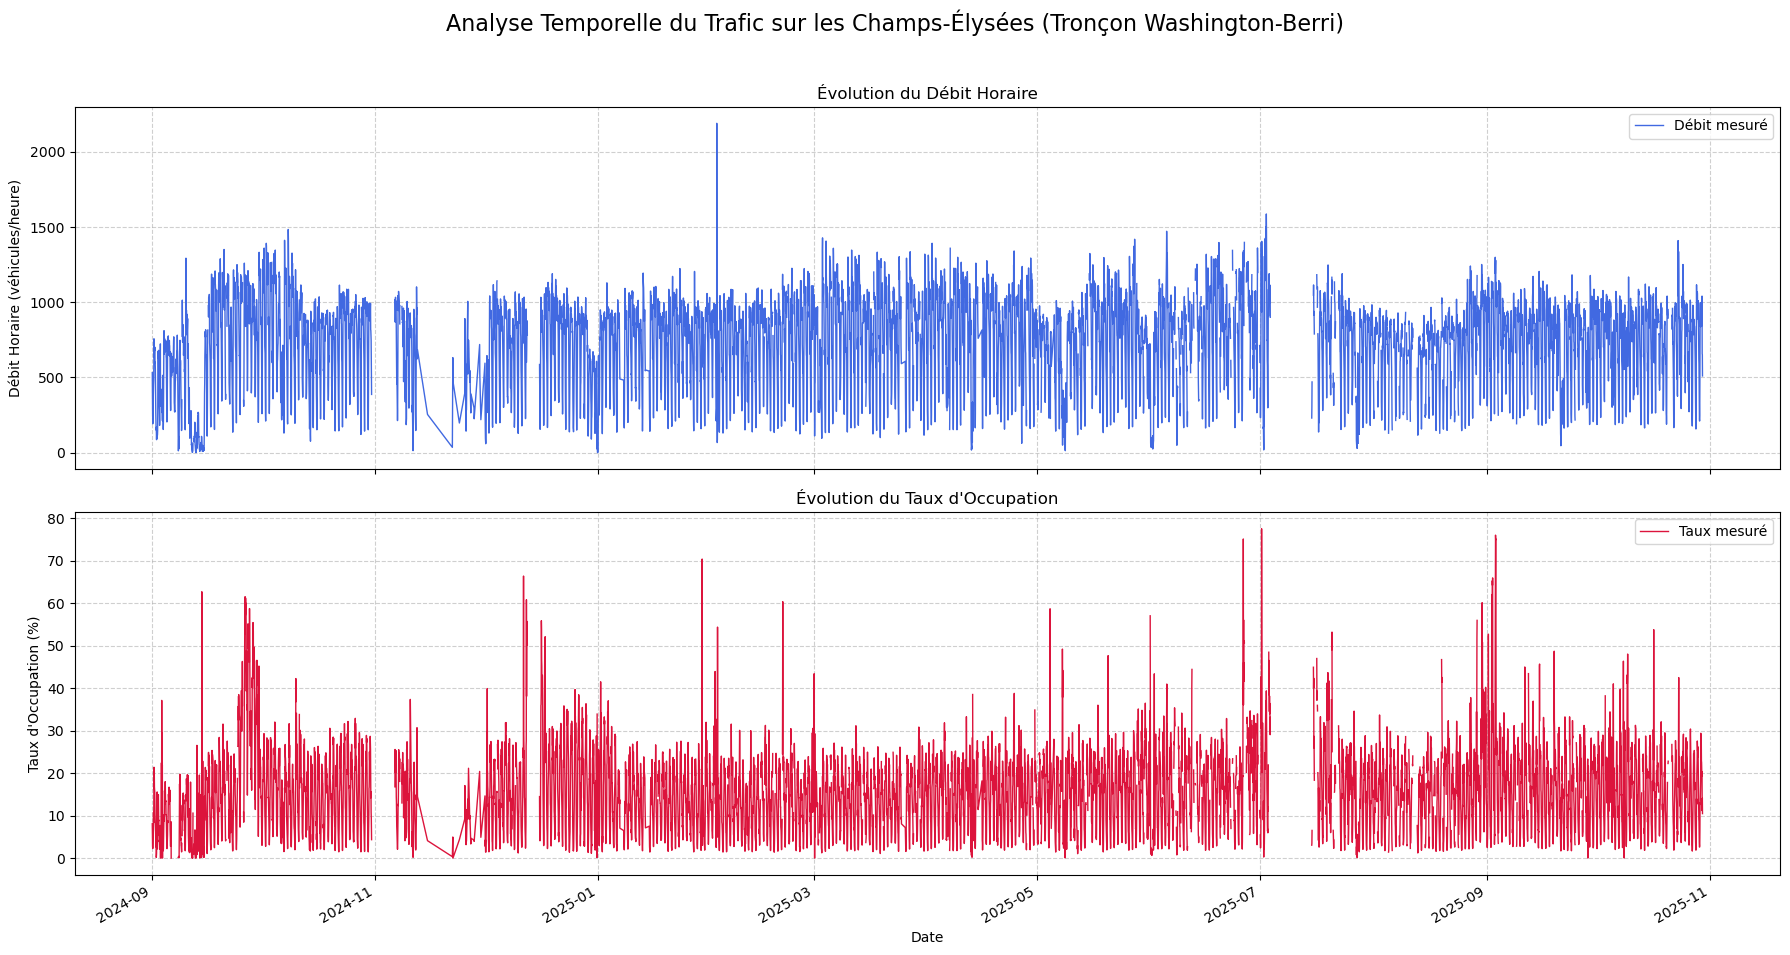

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- 1. CHARGEMENT ET PRÉPARATION DES DONNÉES ---

# Charger le jeu de données
df = pd.read_csv('./dataset/champs_elysees.csv', sep=";")

# Renommer les colonnes pour un accès plus facile (pas d'espaces, pas d'accents)
df.rename(columns={
    'Date et heure de comptage': 'datetime',
    'Débit horaire': 'debit_horaire',
    "Taux d'occupation": 'taux_occupation',
    'Libelle noeud amont': 'noeud_amont',
    'Libelle noeud aval': 'noeud_aval'
}, inplace=True)

# Conversion de la colonne 'datetime' en objet datetime de pandas
df['datetime'] = pd.to_datetime(df['datetime'])

# Filtrage pour ne conserver que le tronçon pertinent, comme spécifié dans le brief 
df_filtered = df[
    (df['noeud_amont'] == 'Av_Champs_Elysees-Washington') &
    (df['noeud_aval'] == 'Av_Champs_Elysees-Berri')
].copy()

# Définir la colonne 'datetime' comme index du DataFrame
df_filtered.set_index('datetime', inplace=True)

# Trier les données par date, crucial pour une série temporelle correcte
df_filtered.sort_index(inplace=True)

print(f"Données chargées et filtrées. {len(df_filtered)} enregistrements pour le tronçon Washington-Berri.")
print("Affichage des premières lignes après préparation :")
print(df_filtered[['debit_horaire', 'taux_occupation']].head())


# --- 2. VISUALISATION DES SÉRIES TEMPORELLES ---

# Créer une figure avec deux sous-graphiques (un pour chaque variable d'intérêt)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)
fig.suptitle('Analyse Temporelle du Trafic sur les Champs-Élysées (Tronçon Washington-Berri)', fontsize=16)

# Graphique 1: Débit Horaire
ax1.plot(df_filtered.index, df_filtered['debit_horaire'], color='royalblue', linewidth=1, label='Débit mesuré')
ax1.set_ylabel('Débit Horaire (véhicules/heure)')
ax1.set_title('Évolution du Débit Horaire')
ax1.grid(True, which='major', linestyle='--', alpha=0.6)
ax1.legend()

# Graphique 2: Taux d'Occupation
ax2.plot(df_filtered.index, df_filtered['taux_occupation'], color='crimson', linewidth=1, label='Taux mesuré')
ax2.set_ylabel("Taux d'Occupation (%)")
ax2.set_title("Évolution du Taux d'Occupation")
ax2.grid(True, which='major', linestyle='--', alpha=0.6)
ax2.legend()

# Améliorer le format de l'axe des x (dates) pour une meilleure lisibilité
plt.xlabel('Date')
fig.autofmt_xdate() # Rotation automatique des dates

# Afficher les graphiques
plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Ajuster pour le titre principal
plt.show()

In [10]:
df[['debit_horaire', 'taux_occupation']].describe()

,debit_horaire,taux_occupation
count,8703.000000,8644.000000
mean,728.031024,15.297325
std,295.519534,9.659342
min,0.000000,0.000000
25%,514.000000,7.184165
50%,798.000000,14.933055
75%,944.000000,21.519027
max,2190.000000,77.545560


Pourcentage de 'debit_horaire' manquant : 6.08%
Pourcentage de 'taux_occupation' manquant : 6.71%


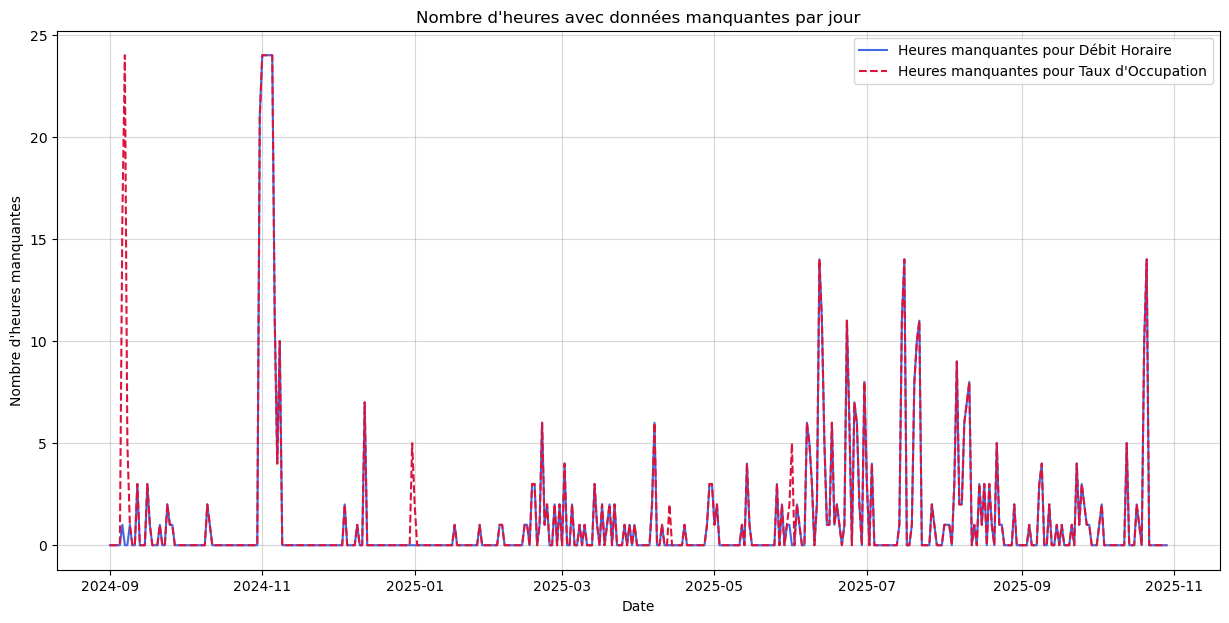

In [13]:
# --- Visualisation des données manquantes ---

df['datetime'] = pd.to_datetime(df['datetime'], utc = True)
df_filtered = df[
    (df['noeud_amont'] == 'Av_Champs_Elysees-Washington') &
    (df['noeud_aval'] == 'Av_Champs_Elysees-Berri')
].copy()
df_filtered.set_index('datetime', inplace=True)
df_filtered.sort_index(inplace=True)

# --- 1. Quantification ---
missing_debit = df_filtered['debit_horaire'].isnull().sum()
missing_taux = df_filtered['taux_occupation'].isnull().sum()
total_rows = len(df_filtered)

print(f"Pourcentage de 'debit_horaire' manquant : {100 * missing_debit / total_rows:.2f}%")
print(f"Pourcentage de 'taux_occupation' manquant : {100 * missing_taux / total_rows:.2f}%")

# --- 2. Visualisation de la distribution des manquants ---
# On crée un DataFrame qui compte les valeurs nulles par jour
missing_by_day = df_filtered[['debit_horaire', 'taux_occupation']].isnull().resample('D').sum()

plt.figure(figsize=(15, 7))
plt.plot(missing_by_day.index, missing_by_day['debit_horaire'], label='Heures manquantes pour Débit Horaire', color='royalblue')
plt.plot(missing_by_day.index, missing_by_day['taux_occupation'], label="Heures manquantes pour Taux d'Occupation", color='crimson', linestyle='--')
plt.title('Nombre d\'heures avec données manquantes par jour')
plt.ylabel('Nombre d\'heures manquantes')
plt.xlabel('Date')
plt.grid(True, alpha=0.5)
plt.legend()
plt.show()


 Profil d'une journée type (moyennes par heure)
      debit_horaire  taux_occupation
hour                                
0            611.89            10.24
1            513.48             8.46
2            413.92             6.57
3            326.42             4.61
4            306.38             4.14
5            407.27             5.13
6            600.21             7.78
7            761.53            11.08
8            832.27            13.61
9            854.53            16.35
10           860.82            18.75
11           899.25            21.59
12           890.11            22.39
13           868.22            21.59
14           890.66            22.64
15           898.08            23.24
16           903.08            24.19
17           926.03            24.23
18           929.06            23.26
19           868.97            20.53
20           783.79            17.21
21           745.38            15.00
22           713.32            13.17
23           688.90       

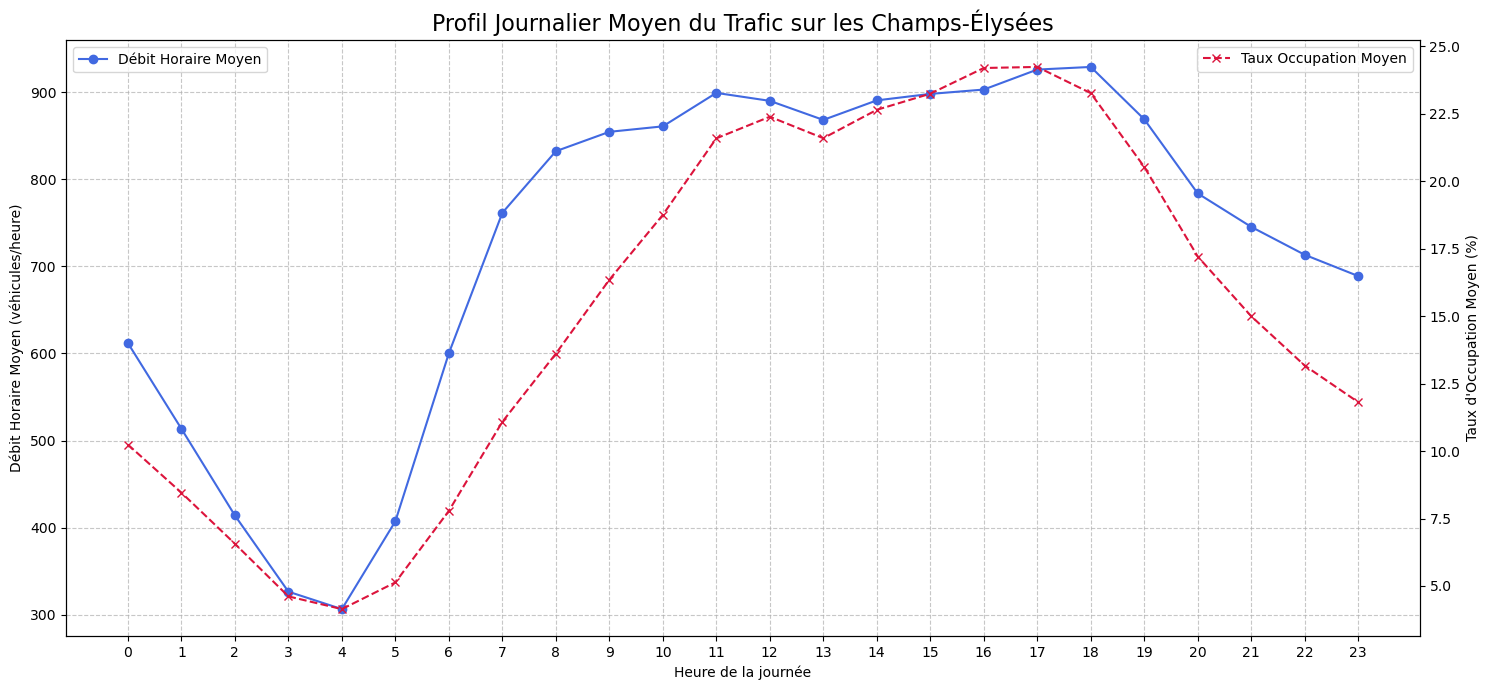


 Valeurs horaires les plus extrêmes

--- 10 heures avec le DÉBIT HORAIRE le plus bas ---
                           debit_horaire  taux_occupation
datetime                                                 
2024-09-13 02:00:00+00:00            0.0          0.00000
2024-12-31 22:00:00+00:00            0.0              NaN
2024-12-31 23:00:00+00:00            0.0              NaN
2024-09-12 02:00:00+00:00            1.0          0.00000
2024-12-31 21:00:00+00:00            1.0              NaN
2024-12-31 20:00:00+00:00            2.0              NaN
2024-09-12 03:00:00+00:00            4.0          0.15278
2024-09-12 01:00:00+00:00            5.0          0.00278
2024-09-12 00:00:00+00:00            7.0          0.11611
2024-09-12 04:00:00+00:00            8.0          0.06889

--- 10 heures avec le DÉBIT HORAIRE le plus élevé ---
                           debit_horaire  taux_occupation
datetime                                                 
2025-02-02 11:00:00+00:00         2190.0   

In [14]:
# Créer une colonne 'hour' pour faciliter le groupement
df_filtered['hour'] = df_filtered.index.hour

# --- 2. PROFIL D'UNE JOURNÉE TYPE (MOYENNE PAR HEURE) ---
print("\n" + "="*50)
print(" Profil d'une journée type (moyennes par heure)")
print("="*50)
# Grouper par heure et calculer la moyenne pour chaque heure
daily_profile = df_filtered.groupby('hour')[['debit_horaire', 'taux_occupation']].mean()
print(daily_profile.round(2))

# Visualisation du profil journalier
fig, ax1 = plt.subplots(figsize=(15, 7))
ax1.plot(daily_profile.index, daily_profile['debit_horaire'], marker='o', linestyle='-', color='royalblue', label='Débit Horaire Moyen')
ax1.set_title('Profil Journalier Moyen du Trafic sur les Champs-Élysées', fontsize=16)
ax1.set_xlabel('Heure de la journée')
ax1.set_ylabel('Débit Horaire Moyen (véhicules/heure)')
ax1.set_xticks(range(24)) # S'assurer que toutes les heures sont affichées
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(loc='upper left')

# Utiliser un deuxième axe Y pour le taux d'occupation pour une meilleure lisibilité
ax2 = ax1.twinx()
ax2.plot(daily_profile.index, daily_profile['taux_occupation'], marker='x', linestyle='--', color='crimson', label='Taux Occupation Moyen')
ax2.set_ylabel("Taux d'Occupation Moyen (%)")
ax2.legend(loc='upper right')
fig.tight_layout()
plt.show()


# --- 3. VALEURS HORAIRES LES PLUS EXTRÊMES ---
print("\n" + "="*50)
print(" Valeurs horaires les plus extrêmes")
print("="*50)

# 10 valeurs les plus basses
print("\n--- 10 heures avec le DÉBIT HORAIRE le plus bas ---")
print(df_filtered.nsmallest(10, 'debit_horaire')[['debit_horaire', 'taux_occupation']])

# 10 valeurs les plus hautes
print("\n--- 10 heures avec le DÉBIT HORAIRE le plus élevé ---")
print(df_filtered.nlargest(10, 'debit_horaire')[['debit_horaire', 'taux_occupation']])


# --- 4. JOURS AVEC LES MOYENNES LES PLUS EXTRÊMES ---
print("\n" + "="*50)
print(" Jours avec les moyennes les plus extrêmes")
print("="*50)

# Agréger les données par jour en calculant la moyenne
daily_avg = df_filtered.resample('D')[['debit_horaire', 'taux_occupation']].mean()

# 10 jours avec les moyennes les plus basses
print("\n--- 10 jours avec le DÉBIT HORAIRE moyen le plus bas ---")
print(daily_avg.nsmallest(10, 'debit_horaire')[['debit_horaire', 'taux_occupation']].round(2))

# 10 jours avec les moyennes les plus hautes
print("\n--- 10 jours avec le DÉBIT HORAIRE moyen le plus élevé ---")
print(daily_avg.nlargest(10, 'debit_horaire')[['debit_horaire', 'taux_occupation']].round(2))